# MATH GR5360 Final Project — Notebook 02

Segmented trend-following strategy notebook. This notebook imports the shared engine, runs one TF sanity check for `Channel WithDDControl`, and then performs the TF walk-forward optimization used in the project-facing workflow.


In [6]:
MARKET_SELECT = 'TY'
QUICK_TEST = True
WALKFORWARD_MODE = 'tf'

DATA_INTERVAL_MINUTES = 5
DATA_FILE_OVERRIDE = None  # e.g. str(PROJECT_ROOT / 'data' / 'TY-5minHLV.csv')
RESULTS_CACHE_DIR = None  # e.g. str(PROJECT_ROOT / 'results_py_corrected')
# Note: the repo currently contains TY-1minHLV.csv but no valid BTC-1minHLV.csv.


In [7]:
from pathlib import Path
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

CWD = Path.cwd().resolve()
PROJECT_ROOT = CWD if (CWD / 'mafn_engine').exists() else CWD.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from mafn_engine import (
    COLUMBIA_CORE,
    COLUMBIA_NAVY,
    COLUMBIA_RED,
    apply_columbia_theme,
    choose_tf_story_configuration,
    default_tf_grid,
    get_market,
    load_ohlc,
    prepare_analysis_frame,
    run_tf_backtest,
    walk_forward,
)

apply_columbia_theme()
MARKET = get_market(MARKET_SELECT)
DATA_PATH = DATA_FILE_OVERRIDE or str(PROJECT_ROOT / 'data')
print(f"Market: {MARKET.ticker} - {MARKET.name} ({MARKET.exchange})")
print(f"PV=${MARKET.PV:,}  Slippage=${MARKET.slpg}  E0=${MARKET.E0:,.0f}")


Market: TY - 10-Year Treasury (CBOT-CME)
PV=$1,000  Slippage=$18.625  E0=$100,000


In [8]:
def _grid_signature(grid: dict[str, np.ndarray]) -> tuple[tuple[str, tuple[float, ...]], ...]:
    signature = []
    for key in sorted(grid):
        values = []
        for value in np.asarray(grid[key]).tolist():
            if isinstance(value, (int, np.integer)):
                values.append(int(value))
            else:
                values.append(float(value))
        signature.append((key, tuple(values)))
    return tuple(signature)


def _market_cache_dir() -> Path | None:
    if not RESULTS_CACHE_DIR:
        return None
    return Path(RESULTS_CACHE_DIR) / f"{MARKET_SELECT}_{int(DATA_INTERVAL_MINUTES)}m"


def _read_ledger_csv(path: Path) -> pd.DataFrame:
    ledger = pd.read_csv(path)
    for column in ['entry_time', 'exit_time']:
        if column in ledger.columns:
            ledger[column] = pd.to_datetime(ledger[column])
    return ledger


def ensure_analysis_state(force: bool = False) -> None:
    global MARKET, full_df, analysis_df, tf_grid, _analysis_signature

    MARKET = get_market(MARKET_SELECT)
    analysis_signature = (MARKET_SELECT, DATA_PATH, int(DATA_INTERVAL_MINUTES))
    if force or globals().get('_analysis_signature') != analysis_signature or 'analysis_df' not in globals():
        full_df = load_ohlc(DATA_PATH, MARKET_SELECT, fallback_synthetic=False, bar_minutes=DATA_INTERVAL_MINUTES)
        analysis_df = prepare_analysis_frame(full_df, MARKET_SELECT)
        _analysis_signature = analysis_signature

    tf_grid = default_tf_grid(MARKET_SELECT, quick=QUICK_TEST, bar_minutes=DATA_INTERVAL_MINUTES)


def ensure_walkforward_state(force: bool = False) -> None:
    global wf_bundle, wf_params, wf_equity, wf_ledger, wf_results, _wf_signature

    ensure_analysis_state(force=force)
    signature = (
        MARKET_SELECT,
        DATA_PATH,
        int(DATA_INTERVAL_MINUTES),
        WALKFORWARD_MODE,
        bool(QUICK_TEST),
        4,
        1,
        _grid_signature(tf_grid),
        str(_market_cache_dir()) if _market_cache_dir() else '',
    )

    if force or globals().get('_wf_signature') != signature or 'wf_bundle' not in globals():
        cache_dir = _market_cache_dir()
        params_path = cache_dir / f"{MARKET_SELECT}_{int(DATA_INTERVAL_MINUTES)}m_walkforward_params.csv" if cache_dir else None
        equity_path = cache_dir / f"{MARKET_SELECT}_{int(DATA_INTERVAL_MINUTES)}m_walkforward_equity.csv" if cache_dir else None
        ledger_path = cache_dir / f"{MARKET_SELECT}_{int(DATA_INTERVAL_MINUTES)}m_walkforward_ledger.csv" if cache_dir else None

        if cache_dir and params_path.exists() and equity_path.exists() and ledger_path.exists():
            wf_params = pd.read_csv(params_path)
            wf_equity = pd.read_csv(equity_path, parse_dates=['DateTime']).set_index('DateTime')
            wf_ledger = _read_ledger_csv(ledger_path)
            wf_bundle = {'params': wf_params, 'equity': wf_equity, 'ledger': wf_ledger}
        else:
            wf_bundle = walk_forward(
                analysis_df,
                MARKET_SELECT,
                mode=WALKFORWARD_MODE,
                tf_grid=tf_grid,
                T_years=4,
                tau_quarters=1,
                quick=QUICK_TEST,
                verbose=True,
            )
            wf_params = wf_bundle['params']
            wf_equity = wf_bundle['equity']
            wf_ledger = wf_bundle['ledger']

        _wf_signature = signature

    wf_params = wf_bundle['params']
    wf_equity = wf_bundle['equity']
    wf_ledger = wf_bundle['ledger']
    wf_results = wf_params


ensure_analysis_state(force=True)

tf_combos = len(tf_grid['L']) * len(tf_grid['S'])
print(f"TF grid combinations: {tf_combos:,}")
print('Project-facing workflow: trend-following only.')
if RESULTS_CACHE_DIR:
    print(f"Using cached walk-forward artifacts from {RESULTS_CACHE_DIR}")


✓ Loaded TY from /Users/nigelli/Desktop/Columbia MAFN/26Spring/MATH5360/Final Project/MATH5360_Final_Project/data/TY-5minHLV.csv
TF grid combinations: 35
Project-facing workflow: trend-following only.


In [9]:
ensure_analysis_state()

story_cfg = choose_tf_story_configuration(MARKET_SELECT, tf_grid=tf_grid, params_df=pd.DataFrame())
tf_sanity = run_tf_backtest(analysis_df, MARKET_SELECT, L=int(story_cfg['L']), S=float(story_cfg['S']))

sanity_summary_df = pd.DataFrame([
    {
        'Family': 'tf',
        'L': int(story_cfg['L']),
        'S': float(story_cfg['S']),
        'Profit': tf_sanity['Profit'],
        'MaxDD': tf_sanity['MaxDD'],
        'Objective': tf_sanity['Objective'],
        'Trades': tf_sanity['NumTrades'],
    },
])
sanity_summary_df


,Family,L,S,Profit,MaxDD,Objective,Trades
0,tf,1440,0.02,56146.1875,24112.8125,2.328479,429


In [10]:
ensure_walkforward_state(force=True)

print()
print('TF WALK-FORWARD COMPLETE')
print('-' * 72)
print(f"Periods: {len(wf_params)}")
print(f"Ledger rows: {len(wf_ledger)}")
wf_params.head()


✓ Loaded TY from /Users/nigelli/Desktop/Columbia MAFN/26Spring/MATH5360/Final Project/MATH5360_Final_Project/data/TY-5minHLV.csv
Walk-Forward [TY] mode=tf: IS=4yr (80,640 bars), OOS=1Q (5,040 bars)
  P1 TF IS_obj=+4.668 OOS_obj=+1.238 votes(tf=19, mr=0)
  P2 TF IS_obj=+5.544 OOS_obj=-0.105 votes(tf=20, mr=0)
  P3 TF IS_obj=+5.526 OOS_obj=+0.728 votes(tf=15, mr=0)
  P4 TF IS_obj=+6.160 OOS_obj=+0.053 votes(tf=16, mr=0)
  P5 TF IS_obj=+6.322 OOS_obj=-0.861 votes(tf=13, mr=0)
  P6 TF IS_obj=+5.362 OOS_obj=-0.417 votes(tf=11, mr=1)
  P7 TF IS_obj=+5.091 OOS_obj=+0.124 votes(tf=12, mr=0)
  P8 TF IS_obj=+5.283 OOS_obj=+0.345 votes(tf=6, mr=0)
  P9 TF IS_obj=+5.366 OOS_obj=-0.813 votes(tf=5, mr=0)
  P10 TF IS_obj=+3.872 OOS_obj=-0.417 votes(tf=4, mr=1)
  P11 TF IS_obj=+4.564 OOS_obj=-0.265 votes(tf=5, mr=0)
  P12 TF IS_obj=+3.725 OOS_obj=-0.404 votes(tf=5, mr=0)
  P13 TF IS_obj=+2.491 OOS_obj=+0.419 votes(tf=3, mr=1)
  P14 TF IS_obj=+2.116 OOS_obj=-0.606 votes(tf=0, mr=3)
  P15 TF IS_obj=+2.4

,Period,Family,Mode,IS_start,IS_end,OOS_start,OOS_end,Decision_family,Decision_reason,Decision_ambiguous,...,IS_Profit,IS_MaxDD,IS_Trades,IS_Combinations,OOS_Objective,OOS_Profit,OOS_MaxDD,OOS_Trades,L,S
0,1,tf,tf,1983-01-03 08:05:00,1987-06-29 12:35:00,1987-06-29 12:40:00,1987-10-08 12:30:00,tf,significant-vote majority,False,...,24373.06250,5221.75000,59,35,1.237612,3967.93750,3206.12500,3,960,0.020
1,2,tf,tf,1983-04-13 13:55:00,1987-10-08 12:30:00,1987-10-08 12:35:00,1988-01-20 12:25:00,tf,significant-vote majority,False,...,25980.06250,4686.37500,40,35,-0.104899,-647.43750,6172.00000,5,1920,0.020
2,3,tf,tf,1983-07-25 13:50:00,1988-01-20 12:25:00,1988-01-20 12:30:00,1988-05-02 12:20:00,tf,significant-vote majority,False,...,23531.43750,4258.09375,41,35,0.728136,1865.78125,2562.40625,2,3200,0.015
3,4,tf,tf,1983-11-02 13:45:00,1988-05-02 12:20:00,1988-05-02 12:25:00,1988-08-11 12:15:00,tf,significant-vote majority,False,...,32164.43750,5221.75000,60,35,0.052757,175.56250,3327.75000,4,960,0.020
4,5,tf,tf,1984-02-14 13:40:00,1988-08-11 12:15:00,1988-08-11 12:20:00,1988-11-18 11:25:00,tf,significant-vote majority,False,...,26919.71875,4258.09375,41,35,-0.860879,-3036.37500,3527.06250,4,3200,0.015


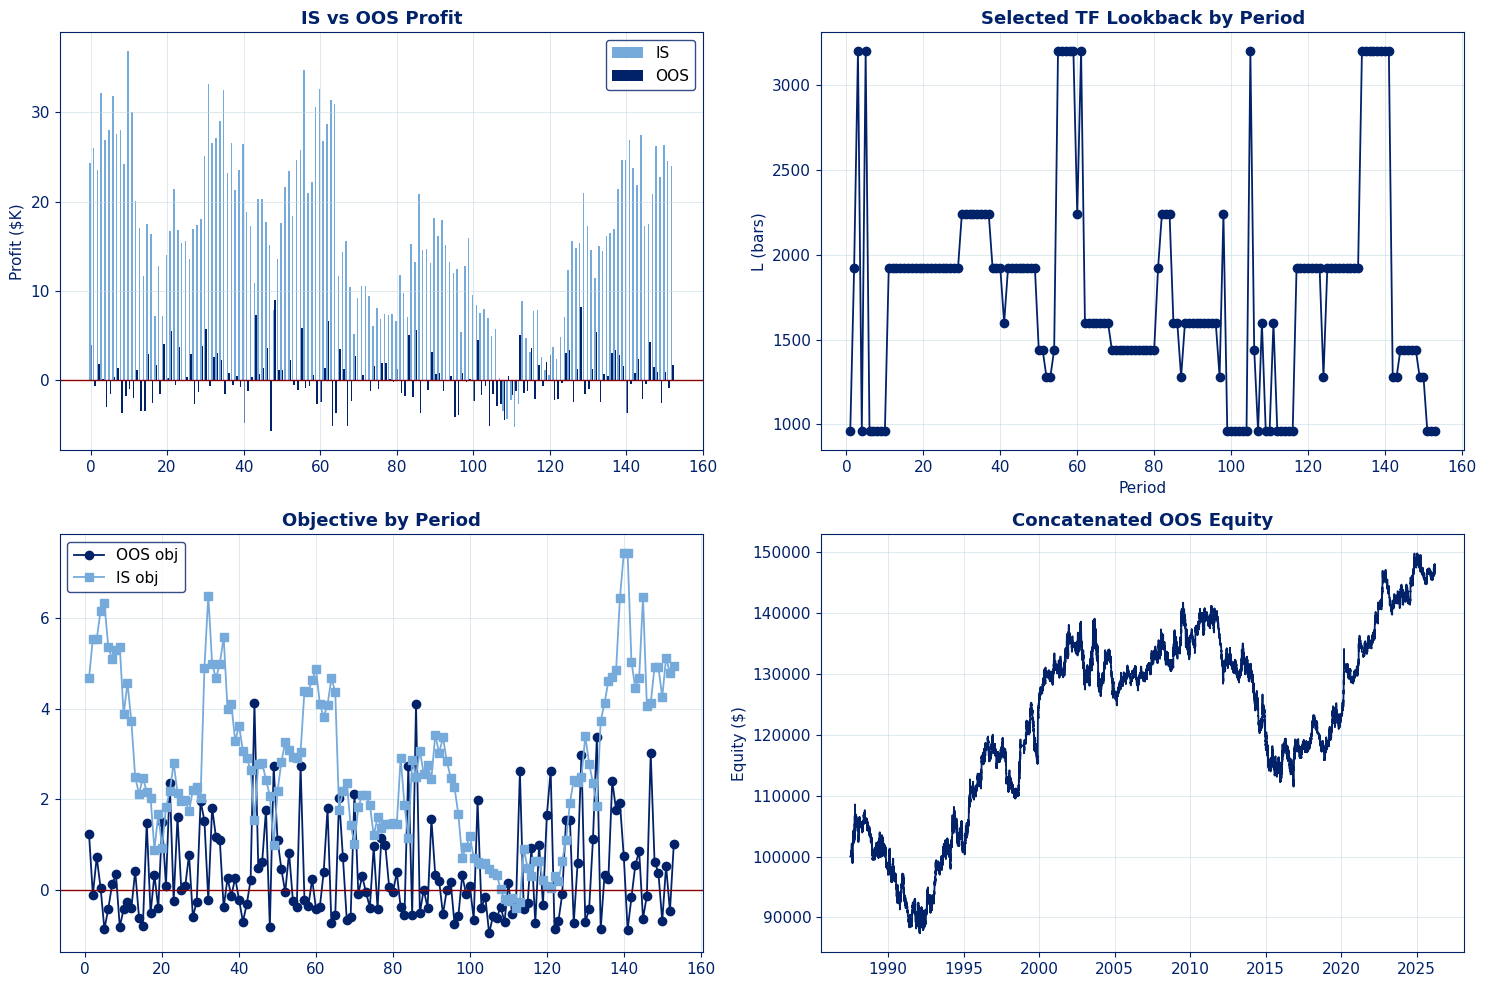

,Period,Family,Mode,IS_start,IS_end,OOS_start,OOS_end,Decision_family,Decision_reason,Decision_ambiguous,...,IS_Profit,IS_MaxDD,IS_Trades,IS_Combinations,OOS_Objective,OOS_Profit,OOS_MaxDD,OOS_Trades,L,S
0,1,tf,tf,1983-01-03 08:05:00,1987-06-29 12:35:00,1987-06-29 12:40:00,1987-10-08 12:30:00,tf,significant-vote majority,False,...,24373.06250,5221.75000,59,35,1.237612,3967.93750,3206.12500,3,960,0.020
1,2,tf,tf,1983-04-13 13:55:00,1987-10-08 12:30:00,1987-10-08 12:35:00,1988-01-20 12:25:00,tf,significant-vote majority,False,...,25980.06250,4686.37500,40,35,-0.104899,-647.43750,6172.00000,5,1920,0.020
2,3,tf,tf,1983-07-25 13:50:00,1988-01-20 12:25:00,1988-01-20 12:30:00,1988-05-02 12:20:00,tf,significant-vote majority,False,...,23531.43750,4258.09375,41,35,0.728136,1865.78125,2562.40625,2,3200,0.015
3,4,tf,tf,1983-11-02 13:45:00,1988-05-02 12:20:00,1988-05-02 12:25:00,1988-08-11 12:15:00,tf,significant-vote majority,False,...,32164.43750,5221.75000,60,35,0.052757,175.56250,3327.75000,4,960,0.020
4,5,tf,tf,1984-02-14 13:40:00,1988-08-11 12:15:00,1988-08-11 12:20:00,1988-11-18 11:25:00,tf,significant-vote majority,False,...,26919.71875,4258.09375,41,35,-0.860879,-3036.37500,3527.06250,4,3200,0.015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148,149,tf,tf,2020-12-18 13:50:00,2024-12-13 13:45:00,2024-12-13 13:50:00,2025-03-18 13:00:00,mr,significant-vote majority,False,...,26248.21875,5346.31250,62,35,0.384221,895.65625,2331.09375,4,1280,0.010
149,150,tf,tf,2021-03-23 11:25:00,2025-03-18 13:00:00,2025-03-18 13:05:00,2025-06-17 13:35:00,mr,significant-vote majority,False,...,22736.12500,5346.31250,64,35,-0.684349,-2547.87500,3723.06250,7,1280,0.010
150,151,tf,tf,2021-06-22 09:05:00,2025-06-17 13:35:00,2025-06-17 13:40:00,2025-09-16 11:25:00,mr,significant-vote majority,False,...,26346.03125,5146.40625,77,35,0.531933,962.50000,1809.43750,2,960,0.010
151,152,tf,tf,2021-09-20 11:35:00,2025-09-16 11:25:00,2025-09-16 11:30:00,2025-12-15 13:40:00,mr,significant-vote majority,True,...,24587.78125,5146.40625,78,35,-0.465871,-861.46875,1849.15625,4,960,0.010


In [11]:
ensure_walkforward_state()

if len(wf_params):
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    x = np.arange(len(wf_params))

    has_is_profit = 'IS_Profit' in wf_params.columns
    has_oos_profit = 'OOS_Profit' in wf_params.columns
    if has_is_profit and has_oos_profit:
        axes[0, 0].bar(x - 0.2, wf_params['IS_Profit'] / 1000, width=0.4, color=COLUMBIA_CORE, label='IS')
        axes[0, 0].bar(x + 0.2, wf_params['OOS_Profit'] / 1000, width=0.4, color=COLUMBIA_NAVY, label='OOS')
        axes[0, 0].legend()
    elif has_oos_profit:
        axes[0, 0].bar(x, wf_params['OOS_Profit'] / 1000, width=0.6, color=COLUMBIA_NAVY, label='OOS')
        axes[0, 0].legend()
    else:
        axes[0, 0].text(0.5, 0.5, 'No profit history generated', ha='center', va='center')
    axes[0, 0].axhline(0.0, color=COLUMBIA_RED, linewidth=1)
    axes[0, 0].set_title('IS vs OOS Profit')
    axes[0, 0].set_ylabel('Profit ($K)')

    if 'L' in wf_params:
        axes[0, 1].plot(wf_params['Period'], wf_params['L'], marker='o', color=COLUMBIA_NAVY)
        axes[0, 1].set_title('Selected TF Lookback by Period')
        axes[0, 1].set_ylabel('L (bars)')
        axes[0, 1].set_xlabel('Period')
    else:
        axes[0, 1].text(0.5, 0.5, 'No TF parameter history generated', ha='center', va='center')
        axes[0, 1].set_axis_off()

    has_is_obj = 'IS_Objective' in wf_params.columns
    has_oos_obj = 'OOS_Objective' in wf_params.columns
    if has_oos_obj:
        axes[1, 0].plot(wf_params['Period'], wf_params['OOS_Objective'], marker='o', color=COLUMBIA_NAVY, label='OOS obj')
    if has_is_obj:
        axes[1, 0].plot(wf_params['Period'], wf_params['IS_Objective'], marker='s', color=COLUMBIA_CORE, label='IS obj')
    axes[1, 0].axhline(0.0, color=COLUMBIA_RED, linewidth=1)
    axes[1, 0].set_title('Objective by Period')
    if has_is_obj or has_oos_obj:
        axes[1, 0].legend(loc='best')

    if len(wf_equity):
        axes[1, 1].plot(wf_equity.index, wf_equity['OOS_Equity'], color=COLUMBIA_NAVY)
        axes[1, 1].set_title('Concatenated OOS Equity')
        axes[1, 1].set_ylabel('Equity ($)')
    else:
        axes[1, 1].text(0.5, 0.5, 'No OOS equity generated', ha='center', va='center')
        axes[1, 1].set_axis_off()

    plt.tight_layout()
    plt.show()

wf_params


In [12]:
ensure_walkforward_state()

if len(wf_ledger):
    print()
    print('OOS TRADE LEDGER PREVIEW')
    print('-' * 72)
    wf_ledger.head(20)
else:
    print('No OOS trades generated.')



OOS TRADE LEDGER PREVIEW
------------------------------------------------------------------------
